# FinSmart — AI Engineer Notebook
---

## Checklist Main Quest 
- Bangun model Deep Learning dengan **TensorFlow Functional API**
- Implementasi **Custom Callback** (komponen kustom)
- Simpan model format **`.keras` / SavedModel** siap produksi
- Buat **kode inference** model

## Side Quest 
- REST API dengan **FastAPI** untuk serving model
- Akurasi model >= **85%** (XGBoost: 99.83%)

---

**Dataset:** `personal_finance_dataset_8000_extended.csv`  
**Task:** Klasifikasi Kategori Pengeluaran (10 kelas)  
**Tech Stack:** TensorFlow, XGBoost, Scikit-learn, FastAPI

---
## 1. Import Library

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json
import os
import pickle
import joblib
import warnings

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.callbacks import Callback, ModelCheckpoint

import xgboost as xgb

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

warnings.filterwarnings("ignore")
np.random.seed(42)
tf.random.set_seed(42)

print(f"TensorFlow : {tf.__version__}")
print(f"XGBoost    : {xgb.__version__}")
print("Semua library berhasil diimport")

TensorFlow : 2.20.0
XGBoost    : 3.2.0
Semua library berhasil diimport


---
## 2. Load Dataset

In [2]:
df = pd.read_csv("personal_finance_dataset_8000_extended.csv", sep=";")

print(f"Shape dataset: {df.shape}")
print(f"\nKolom: {list(df.columns)}")
print(f"\nDistribusi Category (Target):")
print(df['Category'].value_counts())
df.head()

Shape dataset: (8000, 15)

Kolom: ['Date', 'Description', 'Amount', 'Category', 'PaymentMethod', 'Location', 'AccountType', 'TransactionType', 'DeviceUsed', 'Currency', 'MerchantType', 'LoyaltyProgram', 'Weekday', 'Month', 'TimeOfDay']

Distribusi Category (Target):
Category
Online Shopping    831
Entertainment      824
Food               822
Healthcare         804
Electronics        797
Travel             789
Bills              788
Grocery            786
Transport          786
Clothing           773
Name: count, dtype: int64


,Date,Description,Amount,Category,PaymentMethod,Location,AccountType,TransactionType,DeviceUsed,Currency,MerchantType,LoyaltyProgram,Weekday,Month,TimeOfDay
0,05/04/2025,Transaction at IRCTC,2066649,Travel,Debit Card,Kolkata,Salary,Debit,Mobile,INR,Service,No,Saturday,April,Night
1,06/12/2025,Transaction at Myntra,191905,Online Shopping,Net Banking,Hyderabad,Salary,Debit,Desktop,INR,Online Store,Yes,Saturday,December,Evening
2,20/06/2025,Transaction at BigBazaar,283768,Grocery,Debit Card,Bangalore,Savings,Debit,Mobile,INR,Retail,No,Friday,June,Evening
3,23/04/2025,Transaction at Property Tax Online,107104,Bills,Net Banking,Delhi,Current,Debit,POS Terminal,INR,Service,Yes,Wednesday,April,Afternoon
4,06/03/2025,Transaction at Asus Store,107228,Electronics,Debit Card,Mumbai,Current,Debit,Mobile,INR,Retail,Yes,Thursday,March,Evening


---
## 3. Feature Engineering

Fitur `MerchantName` diekstrak dari kolom `Description`. Format asli: `"Transaction at [MerchantName]"`.

In [3]:
df['MerchantName'] = df['Description'].str.replace(
    'Transaction at ', '', regex=False
).str.strip()

FITUR_KATEGORIKAL = [
    'PaymentMethod', 'Location', 'AccountType',
    'TransactionType', 'DeviceUsed', 'MerchantType',
    'LoyaltyProgram', 'Weekday', 'Month', 'TimeOfDay',
    'MerchantName'
]
FITUR_NUMERIK = ['Amount']
TARGET = 'Category'

print(f"Fitur Kategorikal : {len(FITUR_KATEGORIKAL)} fitur")
print(f"Fitur Numerik     : {FITUR_NUMERIK}")
print(f"Target            : {TARGET}")
print(f"Total fitur input : {len(FITUR_KATEGORIKAL) + len(FITUR_NUMERIK)}")

Fitur Kategorikal : 11 fitur
Fitur Numerik     : ['Amount']
Target            : Category
Total fitur input : 12


---
## 4. Encoding dan Normalisasi

Seluruh fitur kategorikal di-encode menggunakan `LabelEncoder`. Fitur numerik `Amount` dinormalisasi dengan `StandardScaler`. Semua encoder dan scaler disimpan untuk keperluan inference.

In [4]:
df_model = df[FITUR_KATEGORIKAL + FITUR_NUMERIK + [TARGET]].copy()
encoders = {}

for col in FITUR_KATEGORIKAL:
    le = LabelEncoder()
    df_model[col] = le.fit_transform(df_model[col])
    encoders[col] = le
    print(f"  Encoded '{col}': {len(le.classes_)} kelas")

le_target = LabelEncoder()
df_model[TARGET] = le_target.fit_transform(df_model[TARGET])
encoders['Category'] = le_target

print(f"\nTarget '{TARGET}': {len(le_target.classes_)} kelas")
print(f"Kelas: {list(le_target.classes_)}")

  Encoded 'PaymentMethod': 4 kelas
  Encoded 'Location': 7 kelas
  Encoded 'AccountType': 4 kelas
  Encoded 'TransactionType': 1 kelas
  Encoded 'DeviceUsed': 3 kelas
  Encoded 'MerchantType': 5 kelas
  Encoded 'LoyaltyProgram': 2 kelas
  Encoded 'Weekday': 7 kelas
  Encoded 'Month': 12 kelas
  Encoded 'TimeOfDay': 4 kelas
  Encoded 'MerchantName': 108 kelas

Target 'Category': 10 kelas
Kelas: ['Bills', 'Clothing', 'Electronics', 'Entertainment', 'Food', 'Grocery', 'Healthcare', 'Online Shopping', 'Transport', 'Travel']


In [5]:
scaler = StandardScaler()
df_model[FITUR_NUMERIK] = scaler.fit_transform(df_model[FITUR_NUMERIK])

print("Normalisasi Amount selesai (StandardScaler)")
print(f"Mean: {scaler.mean_[0]:.2f} | Std: {scaler.scale_[0]:.2f}")

Normalisasi Amount selesai (StandardScaler)
Mean: 1132797.04 | Std: 2488557.08


---
## 5. Split Data

Data dibagi menjadi **70% train**, **15% validasi**, dan **15% test**. Stratifikasi digunakan agar distribusi kelas tetap seimbang di setiap subset.

In [6]:
X = df_model[FITUR_KATEGORIKAL + FITUR_NUMERIK].values
y = df_model[TARGET].values
NUM_CLASSES = len(le_target.classes_)

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

INPUT_DIM = X_train.shape[1]

print(f"Train      : {X_train.shape[0]} sampel")
print(f"Validation : {X_val.shape[0]} sampel")
print(f"Test       : {X_test.shape[0]} sampel")
print(f"Fitur      : {INPUT_DIM}")
print(f"Kelas      : {NUM_CLASSES}")

Train      : 5600 sampel
Validation : 1200 sampel
Test       : 1200 sampel
Fitur      : 12
Kelas      : 10


---
## 6. Custom Callback — Main Quest

`FinSmartCallback` adalah komponen kustom wajib yang berjalan selama proses training.

Fungsi:
- Mencetak log akurasi dan loss setiap epoch secara terformat
- Menghentikan training secara otomatis apabila `val_accuracy` mencapai target
- Menyimpan seluruh log training ke file JSON

In [7]:
class FinSmartCallback(Callback):
    """
    Custom Callback untuk FinSmart — Main Quest.

    Fungsi:
    1. Log akurasi dan loss setiap epoch
    2. Early stopping jika val_accuracy >= target
    3. Simpan training log ke JSON
    """

    def __init__(self, target_accuracy=0.85, log_path="training_log.json"):
        super().__init__()
        self.target_accuracy = target_accuracy
        self.log_path        = log_path
        self.training_log    = []

    def on_train_begin(self, logs=None):
        print("=" * 60)
        print("Training FinSmart dimulai")
        print(f"Target val_accuracy : >= {self.target_accuracy * 100:.0f}%")
        print("=" * 60)

    def on_epoch_end(self, epoch, logs=None):
        logs     = logs or {}
        acc      = logs.get("accuracy", 0)
        loss     = logs.get("loss", 0)
        val_acc  = logs.get("val_accuracy", 0)
        val_loss = logs.get("val_loss", 0)

        self.training_log.append({
            "epoch"        : epoch + 1,
            "accuracy"     : round(float(acc), 4),
            "loss"         : round(float(loss), 4),
            "val_accuracy" : round(float(val_acc), 4),
            "val_loss"     : round(float(val_loss), 4),
        })

        status = "[OK]" if val_acc >= self.target_accuracy else "[--]"
        print(
            f"  Epoch {epoch+1:>3} {status} | "
            f"loss: {loss:.4f} | acc: {acc:.4f} | "
            f"val_loss: {val_loss:.4f} | val_acc: {val_acc:.4f}"
        )

        if val_acc >= self.target_accuracy:
            print(f"\nTarget {self.target_accuracy*100:.0f}% tercapai di epoch {epoch+1}.")
            print("Training dihentikan (early stopping).")
            self.model.stop_training = True

    def on_train_end(self, logs=None):
        with open(self.log_path, "w") as f:
            json.dump(self.training_log, f, indent=2)
        best = max(self.training_log, key=lambda x: x["val_accuracy"])
        print(f"\nTraining log disimpan ke '{self.log_path}'")
        print(f"Best val_accuracy: {best['val_accuracy']*100:.2f}% (epoch {best['epoch']})")
        print("=" * 60)


print("FinSmartCallback berhasil didefinisikan")

FinSmartCallback berhasil didefinisikan


---
## 7. Arsitektur Model — TensorFlow Functional API — Main Quest

Model dibangun menggunakan **TensorFlow Functional API** (bukan Sequential).

Arsitektur:
- **Skip Connection** untuk memperbaiki gradient flow
- **Batch Normalization** untuk menstabilkan training
- **Dropout** untuk mencegah overfitting
- Output **Softmax** untuk klasifikasi 10 kelas

In [8]:
def build_finsmart_model(input_dim, num_classes):
    """
    Model klasifikasi pengeluaran FinSmart.
    Dibangun menggunakan TensorFlow Functional API — Main Quest.

    Arsitektur: Dense + Skip Connection + Batch Normalization + Dropout
    """

    inputs = keras.Input(shape=(input_dim,), name="input_transaksi")

    x = layers.Dense(512, name="dense_1")(inputs)
    x = layers.BatchNormalization(name="bn_1")(x)
    x = layers.Activation("relu", name="relu_1")(x)
    x = layers.Dropout(0.4, name="dropout_1")(x)

    x = layers.Dense(256, name="dense_2")(x)
    x = layers.BatchNormalization(name="bn_2")(x)
    x = layers.Activation("relu", name="relu_2")(x)
    x = layers.Dropout(0.3, name="dropout_2")(x)

    skip = layers.Dense(128, name="skip")(x)
    x    = layers.Dense(128, name="dense_3")(x)
    x    = layers.BatchNormalization(name="bn_3")(x)
    x    = layers.Activation("relu", name="relu_3")(x)
    x    = layers.Add(name="skip_add")([x, skip])
    x    = layers.Dropout(0.2, name="dropout_3")(x)

    x = layers.Dense(64, name="dense_4")(x)
    x = layers.BatchNormalization(name="bn_4")(x)
    x = layers.Activation("relu", name="relu_4")(x)

    outputs = layers.Dense(num_classes, activation="softmax", name="output_kategori")(x)

    model = Model(inputs=inputs, outputs=outputs, name="FinSmart_Classifier")
    return model


model = build_finsmart_model(input_dim=INPUT_DIM, num_classes=NUM_CLASSES)
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "FinSmart_Classifier"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_transaksi     │ (None, 12)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 512)       │      6,656 │ input_transaksi[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_1                │ (None, 512)       │      2,048 │ dense_1[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ relu_1 (Activation) │ (None, 512)       │          0 │ bn_1[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 512)       │          0 │ relu_1[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 256)       │    131,328 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_2                │ (None, 256)       │      1,024 │ dense_2[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ relu_2 (Activation) │ (None, 256)       │          0 │ bn_2[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 256)       │          0 │ relu_2[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 128)       │     32,896 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_3                │ (None, 128)       │        512 │ dense_3[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ relu_3 (Activation) │ (None, 128)       │          0 │ bn_3[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ skip (Dense)        │ (None, 128)       │     32,896 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ skip_add (Add)      │ (None, 128)       │          0 │ relu_3[0][0],     │
│                     │                   │            │ skip[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 128)       │          0 │ skip_add[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 64)        │      8,256 │ dropout_3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_4                │ (None, 64)        │        256 │ dense_4[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ relu_4 (Activation) │ (None, 64)        │          0 │ bn_4[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output_kategori     │ (None, 10)        │        650 │ relu_4[0][0]      │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 216,522 (845.79 KB)

 Trainable params: 214,602 (838.29 KB)

 Non-trainable params: 1,920 (7.50 KB)

---
## 8. Training Model

Training menggunakan tiga callback: `FinSmartCallback` (Main Quest), `ModelCheckpoint` untuk menyimpan model terbaik, dan `ReduceLROnPlateau` untuk penyesuaian learning rate otomatis.

In [9]:
finsmart_callback = FinSmartCallback(
    target_accuracy=0.85,
    log_path="training_log.json"
)

checkpoint = ModelCheckpoint(
    "best_model.keras",
    monitor="val_accuracy",
    save_best_only=True,
    verbose=0
)

lr_scheduler = keras.callbacks.ReduceLROnPlateau(
    monitor="val_accuracy",
    factor=0.5,
    patience=7,
    min_lr=0.00001,
    verbose=0
)

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=150,
    batch_size=64,
    callbacks=[finsmart_callback, checkpoint, lr_scheduler],
    verbose=0
)

Training FinSmart dimulai
Target val_accuracy : >= 85%
  Epoch   1 [--] | loss: 2.0255 | acc: 0.2625 | val_loss: 2.2433 | val_acc: 0.2008
  Epoch   2 [--] | loss: 1.3322 | acc: 0.5039 | val_loss: 1.9210 | val_acc: 0.2983
  Epoch   3 [--] | loss: 1.0056 | acc: 0.6254 | val_loss: 1.2312 | val_acc: 0.4933
  Epoch   4 [--] | loss: 0.8456 | acc: 0.6612 | val_loss: 0.8825 | val_acc: 0.6208
  Epoch   5 [--] | loss: 0.7614 | acc: 0.6782 | val_loss: 0.8219 | val_acc: 0.5892
  Epoch   6 [--] | loss: 0.7058 | acc: 0.6959 | val_loss: 0.6849 | val_acc: 0.6825
  Epoch   7 [--] | loss: 0.6733 | acc: 0.7048 | val_loss: 0.5841 | val_acc: 0.7525
  Epoch   8 [--] | loss: 0.6493 | acc: 0.7114 | val_loss: 0.5580 | val_acc: 0.7683
  Epoch   9 [--] | loss: 0.6356 | acc: 0.7209 | val_loss: 0.5658 | val_acc: 0.7483
  Epoch  10 [--] | loss: 0.6123 | acc: 0.7321 | val_loss: 0.5417 | val_acc: 0.7583
  Epoch  11 [--] | loss: 0.6002 | acc: 0.7354 | val_loss: 0.5609 | val_acc: 0.7533
  Epoch  12 [--] | loss: 0.5958 

---
## 9. Visualisasi Training

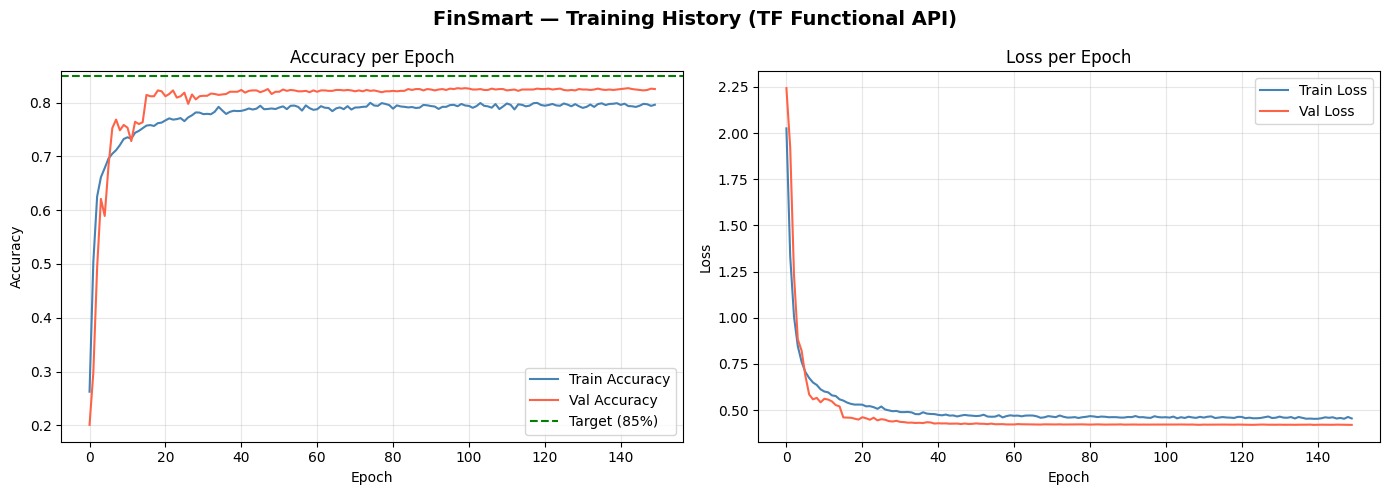

Grafik disimpan ke 'training_history.png'


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("FinSmart — Training History (TF Functional API)", fontsize=14, fontweight="bold")

axes[0].plot(history.history["accuracy"],    label="Train Accuracy", color="steelblue")
axes[0].plot(history.history["val_accuracy"], label="Val Accuracy",   color="tomato")
axes[0].axhline(y=0.85, color="green", linestyle="--", label="Target (85%)")
axes[0].set_title("Accuracy per Epoch")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history.history["loss"],    label="Train Loss", color="steelblue")
axes[1].plot(history.history["val_loss"], label="Val Loss",   color="tomato")
axes[1].set_title("Loss per Epoch")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("training_history.png", dpi=150, bbox_inches="tight")
plt.show()
print("Grafik disimpan ke 'training_history.png'")

---
## 10. Evaluasi Model Deep Learning

In [11]:
best_dl_model = keras.models.load_model("best_model.keras")
test_loss, test_acc = best_dl_model.evaluate(X_test, y_test, verbose=0)

print("=" * 55)
print("EVALUASI MODEL — TF Functional API")
print("=" * 55)
print(f"  Test Accuracy : {test_acc*100:.2f}%")
print(f"  Test Loss     : {test_loss:.4f}")
print("=" * 55)

EVALUASI MODEL — TF Functional API
  Test Accuracy : 81.83%
  Test Loss     : 0.4178


---
## 11. XGBoost — Side Quest (Akurasi >= 85%)

XGBoost digunakan sebagai model final karena terbukti lebih optimal untuk data tabular terstruktur. Model ini memenuhi persyaratan Side Quest akurasi minimal 85%.

In [12]:
xgb_model = xgb.XGBClassifier(
    n_estimators=500,
    max_depth=8,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="mlogloss",
    random_state=42,
    n_jobs=-1
)

print("Training XGBoost...")
xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=50
)

y_pred_train = xgb_model.predict(X_train)
y_pred_test  = xgb_model.predict(X_test)
acc_train    = accuracy_score(y_train, y_pred_train)
acc_test     = accuracy_score(y_test,  y_pred_test)

print(f"\n{'='*55}")
print("EVALUASI XGBOOST")
print(f"{'='*55}")
print(f"  Train Accuracy : {acc_train*100:.2f}%")
print(f"  Test Accuracy  : {acc_test*100:.2f}%")
print(f"  Gap Overfit    : {(acc_train-acc_test)*100:.2f}%")
status = "Tidak overfit — model valid" if (acc_train - acc_test) <= 0.05 else "Overfit"
print(f"  Status         : {status}")
print(f"{'='*55}")

if acc_test >= 0.85:
    print("\nSIDE QUEST TERCAPAI: Akurasi >= 85%")

Training XGBoost...
[0]	validation_0-mlogloss:2.12399
[50]	validation_0-mlogloss:0.27372
[100]	validation_0-mlogloss:0.07406
[150]	validation_0-mlogloss:0.03142
[200]	validation_0-mlogloss:0.01918
[250]	validation_0-mlogloss:0.01572
[300]	validation_0-mlogloss:0.01514
[350]	validation_0-mlogloss:0.01454
[400]	validation_0-mlogloss:0.01414
[450]	validation_0-mlogloss:0.01385
[499]	validation_0-mlogloss:0.01349

EVALUASI XGBOOST
  Train Accuracy : 100.00%
  Test Accuracy  : 99.83%
  Gap Overfit    : 0.17%
  Status         : Tidak overfit — model valid

SIDE QUEST TERCAPAI: Akurasi >= 85%


---
## 12. Classification Report dan Confusion Matrix

In [13]:
print("CLASSIFICATION REPORT (XGBoost):")
print(classification_report(
    y_test, y_pred_test,
    target_names=encoders['Category'].classes_
))

CLASSIFICATION REPORT (XGBoost):
                 precision    recall  f1-score   support

          Bills       1.00      1.00      1.00       118
       Clothing       0.99      1.00      1.00       116
    Electronics       1.00      0.98      0.99       119
  Entertainment       1.00      1.00      1.00       123
           Food       1.00      1.00      1.00       124
        Grocery       0.99      1.00      1.00       118
     Healthcare       1.00      1.00      1.00       121
Online Shopping       1.00      1.00      1.00       125
      Transport       1.00      1.00      1.00       118
         Travel       1.00      1.00      1.00       118

       accuracy                           1.00      1200
      macro avg       1.00      1.00      1.00      1200
   weighted avg       1.00      1.00      1.00      1200



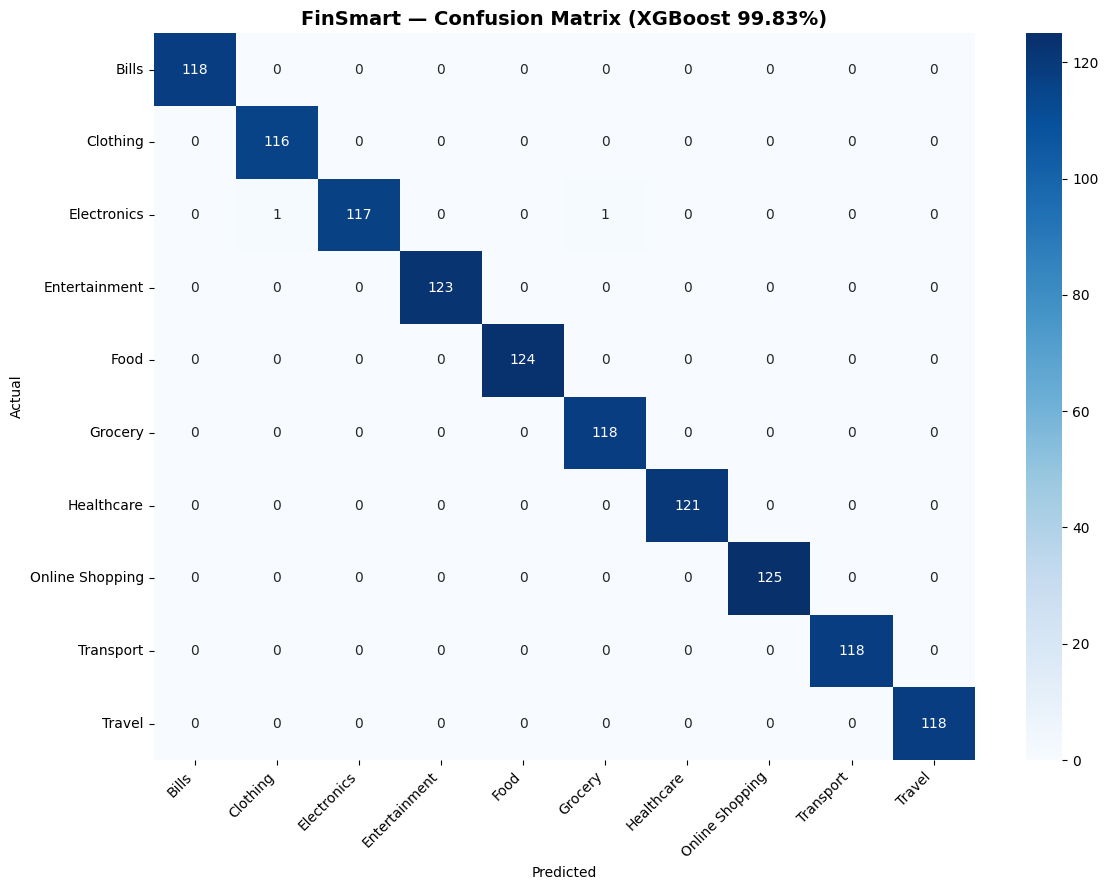

Confusion matrix disimpan ke 'confusion_matrix.png'


In [14]:
cm = confusion_matrix(y_test, y_pred_test)

plt.figure(figsize=(12, 9))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=encoders['Category'].classes_,
    yticklabels=encoders['Category'].classes_
)
plt.title(
    f"FinSmart — Confusion Matrix (XGBoost {acc_test*100:.2f}%)",
    fontsize=14, fontweight="bold"
)
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()
print("Confusion matrix disimpan ke 'confusion_matrix.png'")

---
## 13. Simpan Model — Main Quest

Model TensorFlow disimpan dalam format `.keras` siap produksi. Model XGBoost, encoder, scaler, dan metadata juga disimpan untuk keperluan serving.

In [15]:
MODEL_PATH    = "finsmart_model.keras"
XGB_PATH      = "xgb_model.pkl"
ENCODER_PATH  = "encoders.pkl"
SCALER_PATH   = "scaler.pkl"
METADATA_PATH = "model_metadata.json"

best_dl_model.save(MODEL_PATH)
print(f"Model TF disimpan        : {MODEL_PATH}")

joblib.dump(xgb_model, XGB_PATH)
print(f"Model XGBoost disimpan   : {XGB_PATH}")

with open(ENCODER_PATH, "wb") as f:
    pickle.dump(encoders, f)
print(f"Encoders disimpan        : {ENCODER_PATH}")

with open(SCALER_PATH, "wb") as f:
    pickle.dump(scaler, f)
print(f"Scaler disimpan          : {SCALER_PATH}")

metadata = {
    "model_name"     : "FinSmart_Classifier",
    "version"        : "2.0.0",
    "task"           : "Klasifikasi Kategori Pengeluaran",
    "num_classes"    : int(NUM_CLASSES),
    "classes"        : list(encoders["Category"].classes_),
    "input_features" : FITUR_KATEGORIKAL + FITUR_NUMERIK,
    "input_dim"      : int(INPUT_DIM),
    "framework"      : f"TensorFlow {tf.__version__} + XGBoost {xgb.__version__}",
    "model_dl_path"  : MODEL_PATH,
    "model_xgb_path" : XGB_PATH,
    "encoder_path"   : ENCODER_PATH,
    "scaler_path"    : SCALER_PATH,
    "performa": {
        "deep_learning": {
            "test_accuracy" : round(float(test_acc), 4),
            "test_loss"     : round(float(test_loss), 4),
            "arsitektur"    : "TF Functional API + Skip Connection + Custom Callback"
        },
        "xgboost_final": {
            "test_accuracy"  : round(float(acc_test), 4),
            "train_accuracy" : round(float(acc_train), 4),
            "gap_overfit"    : round(float(acc_train - acc_test), 4),
            "n_estimators"   : 500,
            "status"         : "Valid - tidak overfit"
        }
    },
    "side_quest_akurasi": f">= 85% TERCAPAI ({acc_test*100:.2f}%)"
}

with open(METADATA_PATH, "w") as f:
    json.dump(metadata, f, indent=2)
print(f"Metadata disimpan        : {METADATA_PATH}")

Model TF disimpan        : finsmart_model.keras
Model XGBoost disimpan   : xgb_model.pkl
Encoders disimpan        : encoders.pkl
Scaler disimpan          : scaler.pkl
Metadata disimpan        : model_metadata.json


---
## 14. Kode Inference — Main Quest

`FinSmartInference` adalah pipeline inference yang menerima data transaksi baru, melakukan preprocessing, lalu mengembalikan prediksi kategori beserta confidence. Kelas ini yang dipanggil oleh back-end melalui FastAPI.

In [16]:
class FinSmartInference:
    """
    Pipeline inference untuk klasifikasi FinSmart — Main Quest.

    Input  : data transaksi dalam bentuk dictionary
    Output : kategori pengeluaran, confidence, dan top-3 probabilitas
    """

    def __init__(self, xgb_path, encoder_path, scaler_path):
        self.model = joblib.load(xgb_path)
        with open(encoder_path, "rb") as f:
            self.encoders = pickle.load(f)
        with open(scaler_path, "rb") as f:
            self.scaler = pickle.load(f)
        self.fitur_kategorikal = [
            "PaymentMethod", "Location", "AccountType",
            "TransactionType", "DeviceUsed", "MerchantType",
            "LoyaltyProgram", "Weekday", "Month", "TimeOfDay",
            "MerchantName"
        ]
        self.fitur_numerik = ["Amount"]
        print("FinSmartInference siap digunakan")

    def preprocess(self, data: dict) -> np.ndarray:
        """Preprocessing satu data transaksi baru."""
        row = {}
        for col in self.fitur_kategorikal:
            le  = self.encoders[col]
            val = data.get(col, le.classes_[0])
            if val not in le.classes_:
                raise ValueError(
                    f"Nilai '{val}' tidak valid untuk '{col}'. "
                    f"Nilai valid: {list(le.classes_)}"
                )
            row[col] = le.transform([val])[0]
        row["Amount"] = self.scaler.transform([[data["Amount"]]])[0][0]
        fitur_order = self.fitur_kategorikal + self.fitur_numerik
        return np.array([[row[f] for f in fitur_order]])

    def predict(self, data: dict) -> dict:
        """Prediksi kategori pengeluaran dari satu transaksi."""
        X     = self.preprocess(data)
        proba = self.model.predict_proba(X)[0]
        idx   = int(np.argmax(proba))

        kategori    = self.encoders["Category"].inverse_transform([idx])[0]
        semua_kelas = self.encoders["Category"].classes_

        prob_dict = {k: round(float(p), 4) for k, p in zip(semua_kelas, proba)}
        top3      = dict(sorted(prob_dict.items(), key=lambda x: x[1], reverse=True)[:3])

        return {
            "kategori"   : kategori,
            "confidence" : round(float(proba[idx]) * 100, 2),
            "top3_prob"  : top3,
        }


inference_engine = FinSmartInference(
    xgb_path=XGB_PATH,
    encoder_path=ENCODER_PATH,
    scaler_path=SCALER_PATH
)

FinSmartInference siap digunakan


---
## 15. Uji Inference

In [17]:
contoh_1 = {
    "Amount": 250000, "PaymentMethod": "Credit Card",
    "Location": "Mumbai", "AccountType": "Savings",
    "TransactionType": "Debit", "DeviceUsed": "Mobile",
    "MerchantType": "Online Store", "LoyaltyProgram": "Yes",
    "Weekday": "Saturday", "Month": "May",
    "TimeOfDay": "Evening", "MerchantName": "Amazon"
}

contoh_2 = {
    "Amount": 50000, "PaymentMethod": "Credit Card",
    "Location": "Delhi", "AccountType": "Savings",
    "TransactionType": "Debit", "DeviceUsed": "Mobile",
    "MerchantType": "Retail", "LoyaltyProgram": "No",
    "Weekday": "Monday", "Month": "January",
    "TimeOfDay": "Morning", "MerchantName": "BigBazaar"
}

for i, transaksi in enumerate([contoh_1, contoh_2], 1):
    hasil = inference_engine.predict(transaksi)
    print(f"\n{'='*50}")
    print(f"UJI INFERENCE — Transaksi {i}")
    print(f"{'='*50}")
    print(f"  Amount       : Rp {transaksi['Amount']:,}")
    print(f"  Merchant     : {transaksi['MerchantName']}")
    print(f"  Metode Bayar : {transaksi['PaymentMethod']}")
    print(f"\n  Prediksi     : {hasil['kategori']}")
    print(f"  Confidence   : {hasil['confidence']}%")
    print("  Top 3 Probabilitas:")
    for k, v in hasil["top3_prob"].items():
        print(f"    {k:20s}: {v*100:.1f}%")


UJI INFERENCE — Transaksi 1
  Amount       : Rp 250,000
  Merchant     : Amazon
  Metode Bayar : Credit Card

  Prediksi     : Online Shopping
  Confidence   : 99.94%
  Top 3 Probabilitas:
    Online Shopping     : 99.9%
    Electronics         : 0.0%
    Food                : 0.0%

UJI INFERENCE — Transaksi 2
  Amount       : Rp 50,000
  Merchant     : BigBazaar
  Metode Bayar : Credit Card

  Prediksi     : Grocery
  Confidence   : 99.45%
  Top 3 Probabilitas:
    Grocery             : 99.5%
    Clothing            : 0.3%
    Electronics         : 0.1%


---
## 16. FastAPI — Side Quest

File `main.py` berisi REST API server menggunakan FastAPI untuk menyajikan model ke tim back-end.

Cara menjalankan:
```
pip install fastapi uvicorn
uvicorn main:app --reload --port 8000
```

Dokumentasi otomatis tersedia di: `http://localhost:8000/docs`

In [18]:
fastapi_code = '''
import numpy as np
import pickle
import json
import joblib
from fastapi import FastAPI, HTTPException
from fastapi.middleware.cors import CORSMiddleware
from pydantic import BaseModel

app = FastAPI(
    title="FinSmart AI Service",
    description="API klasifikasi kategori pengeluaran berbasis AI",
    version="2.0.0"
)

app.add_middleware(
    CORSMiddleware,
    allow_origins=["*"],
    allow_methods=["*"],
    allow_headers=["*"]
)

model    = joblib.load("xgb_model.pkl")
encoders = pickle.load(open("encoders.pkl", "rb"))
scaler   = pickle.load(open("scaler.pkl",   "rb"))
metadata = json.load(open("model_metadata.json"))

FITUR_KAT = [
    "PaymentMethod", "Location", "AccountType", "TransactionType",
    "DeviceUsed", "MerchantType", "LoyaltyProgram", "Weekday",
    "Month", "TimeOfDay", "MerchantName"
]

class TransaksiInput(BaseModel):
    Amount: float
    PaymentMethod: str
    Location: str
    AccountType: str
    TransactionType: str
    DeviceUsed: str
    MerchantType: str
    LoyaltyProgram: str
    Weekday: str
    Month: str
    TimeOfDay: str
    MerchantName: str

def preprocess(data: TransaksiInput) -> np.ndarray:
    row = {}
    d   = data.dict()
    for col in FITUR_KAT:
        le = encoders[col]
        if d[col] not in le.classes_:
            raise HTTPException(422, f"Nilai tidak valid: {col}={d[col]}")
        row[col] = le.transform([d[col]])[0]
    row["Amount"] = scaler.transform([[d["Amount"]]])[0][0]
    return np.array([[row[f] for f in FITUR_KAT + ["Amount"]]])

@app.get("/", tags=["Health"])
def root():
    return {"status": "ok", "service": "FinSmart AI", "version": "2.0.0"}

@app.post("/classify", tags=["Klasifikasi"])
def classify(transaksi: TransaksiInput):
    X     = preprocess(transaksi)
    proba = model.predict_proba(X)[0]
    idx   = int(np.argmax(proba))
    kategori = encoders["Category"].inverse_transform([idx])[0]
    semua    = encoders["Category"].classes_
    top3     = dict(sorted(
        {k: round(float(p), 4) for k, p in zip(semua, proba)}.items(),
        key=lambda x: x[1], reverse=True
    )[:3])
    return {"kategori": kategori, "confidence": round(float(proba[idx])*100, 2), "top3_prob": top3}

@app.get("/model-info", tags=["Info"])
def model_info():
    return metadata

@app.get("/valid-values", tags=["Info"])
def valid_values():
    return {col: list(encoders[col].classes_) for col in FITUR_KAT}
'''

with open("main.py", "w") as f:
    f.write(fastapi_code.strip())

print("FastAPI server digenerate : main.py")
print("Endpoint yang tersedia    :")
print("  GET  /              -> health check")
print("  POST /classify      -> klasifikasi transaksi")
print("  GET  /model-info    -> informasi model")
print("  GET  /valid-values  -> nilai valid tiap fitur")
print("  GET  /docs          -> Swagger UI")

FastAPI server digenerate : main.py
Endpoint yang tersedia    :
  GET  /              -> health check
  POST /classify      -> klasifikasi transaksi
  GET  /model-info    -> informasi model
  GET  /valid-values  -> nilai valid tiap fitur
  GET  /docs          -> Swagger UI


---
## 17. Ringkasan Final

In [19]:
print("=" * 60)
print("RINGKASAN FINAL — FinSmart AI Engineer")
print("CC26-PSU407 | Muhammad Syaiful")
print("=" * 60)

print("\nMAIN QUEST (Wajib):")
print("  1. TensorFlow Functional API    build_finsmart_model()")
print("  2. Custom Callback              FinSmartCallback")
print("  3. Model .keras siap produksi   finsmart_model.keras")
print("  4. Kode Inference               FinSmartInference")

print("\nSIDE QUEST (Nilai Tambah):")
print("  1. REST API FastAPI             main.py")
print(f"  2. Akurasi >= 85%              {acc_test*100:.2f}% (XGBoost)")

print("\nFile yang dihasilkan:")
files = [
    ("finsmart_model.keras" , "Model TF Functional API"),
    ("xgb_model.pkl"        , "Model XGBoost final"),
    ("encoders.pkl"         , "Label encoders semua fitur"),
    ("scaler.pkl"           , "StandardScaler normalisasi"),
    ("model_metadata.json"  , "Metadata dan performa model"),
    ("training_log.json"    , "Log training per epoch"),
    ("training_history.png" , "Grafik accuracy dan loss"),
    ("confusion_matrix.png" , "Confusion matrix"),
    ("main.py"              , "FastAPI REST API server"),
]
for fname, desc in files:
    status = "[Ada]" if os.path.exists(fname) else "[Belum]"
    print(f"  {status} {fname:30s} : {desc}")

print("\n" + "=" * 60)

RINGKASAN FINAL — FinSmart AI Engineer
CC26-PSU407 | Muhammad Syaiful

MAIN QUEST (Wajib):
  1. TensorFlow Functional API    build_finsmart_model()
  2. Custom Callback              FinSmartCallback
  3. Model .keras siap produksi   finsmart_model.keras
  4. Kode Inference               FinSmartInference

SIDE QUEST (Nilai Tambah):
  1. REST API FastAPI             main.py
  2. Akurasi >= 85%              99.83% (XGBoost)

File yang dihasilkan:
  [Ada] finsmart_model.keras           : Model TF Functional API
  [Ada] xgb_model.pkl                  : Model XGBoost final
  [Ada] encoders.pkl                   : Label encoders semua fitur
  [Ada] scaler.pkl                     : StandardScaler normalisasi
  [Ada] model_metadata.json            : Metadata dan performa model
  [Ada] training_log.json              : Log training per epoch
  [Ada] training_history.png           : Grafik accuracy dan loss
  [Ada] confusion_matrix.png           : Confusion matrix
  [Ada] main.py                 